# NFL Super Bowl Prediction Model

This notebook builds a machine learning model to predict Super Bowl winners using historical NFL data.

## Approach

* Uses **Random Forest** for feature selection to identify the most predictive stats
* Trains a **Logistic Regression** model on selected features
* Features are calculated from all prior games in the season (regular season + playoff games leading up to target game)
* Model is trained on both regular season and playoff games to learn game dynamics across all contexts

## Model Design

### Feature Calculation

All features are calculated using all prior games from the current season:

* **Early season games:** Only a few games of data available
* **Super Bowl:** Full regular season (18 games) + all playoff games leading up to the championship
* **Features:** Cumulative statistics from all games played before the target game

### Neutral-Site Adjustment for Super Bowl

The Super Bowl is played at a neutral site, but the model was trained on regular season and playoff games with home/away designations. To remove home-field bias:

1. Calculate prediction with Team A as "home": `p1 = P(A wins | A home)`
2. Calculate prediction with Team B as "home": `p2 = P(B wins | B home)`  
3. Average both orientations: `P(A wins neutral) = (p1 + (1 - p2)) / 2`

This approach leverages the trained model while eliminating home-field advantage through symmetric evaluation.

### Training Data
The model learns from **all completed games** across multiple seasons:
- Regular season games (~272 per season)
- Wild Card games (~6 per season)
- Divisional Round games (~4 per season)
- Conference Championships (~2 per season)
- Super Bowl (~1 per season)

### Temporal Ordering
All features end with `_prior` suffix to indicate they only use data from games **before** the current game being predicted. This prevents data leakage and ensures the model only uses information that would be available at prediction time.

In [ ]:
# Install NFL package for the version of Python being used by Anacondas

import sys
!{sys.executable} -m pip install nflreadpy

In [ ]:
import sys
!{sys.executable} -m pip install pyarrow

In [44]:
# Import libraries
import nflreadpy as nfl


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [45]:
# Import NFL datasets for inspection and analysis

team_stats = nfl.load_team_stats([2021, 2022, 2023, 2024, 2025]).to_pandas()

schedules = nfl.load_schedules([2021, 2022, 2023, 2024, 2025]).to_pandas()

player_stats = nfl.load_player_stats([2021, 2022, 2023, 2024, 2025]).to_pandas()

#Fantasy football rankings
ff_rankings = nfl.load_ff_rankings().to_pandas()

In [46]:
print(schedules.head())

           game_id  season game_type  week     gameday   weekday gametime  \
0   2021_01_DAL_TB    2021       REG     1  2021-09-09  Thursday    20:20   
1  2021_01_PHI_ATL    2021       REG     1  2021-09-12    Sunday    13:00   
2  2021_01_PIT_BUF    2021       REG     1  2021-09-12    Sunday    13:00   
3  2021_01_NYJ_CAR    2021       REG     1  2021-09-12    Sunday    13:00   
4  2021_01_MIN_CIN    2021       REG     1  2021-09-12    Sunday    13:00   

  away_team  away_score home_team  ...  wind  away_qb_id  home_qb_id  \
0       DAL        29.0        TB  ...   9.0  00-0033077  00-0019596   
1       PHI        32.0       ATL  ...   NaN  00-0036389  00-0026143   
2       PIT        23.0       BUF  ...  17.0  00-0022924  00-0034857   
3       NYJ        14.0       CAR  ...   0.0  00-0037013  00-0034869   
4       MIN        24.0       CIN  ...  15.0  00-0029604  00-0036442   

         away_qb_name  home_qb_name     away_coach      home_coach  \
0        Dak Prescott     Tom Brad

In [47]:
print(team_stats.head())

   season  week team season_type opponent_team  completions  attempts  \
0    2021     1  ARI         REG           TEN           21        32   
1    2021     1  ATL         REG           PHI           21        35   
2    2021     1  BAL         REG            LV           19        30   
3    2021     1  BUF         REG           PIT           30        51   
4    2021     1  CAR         REG           NYJ           24        35   

   passing_yards  passing_tds  passing_interceptions  ...  pat_made  pat_att  \
0            289            4                      1  ...         5        5   
1            164            0                      0  ...         0        0   
2            235            1                      0  ...         3        3   
3            270            1                      0  ...         1        1   
4            279            1                      0  ...         1        2   

   pat_missed  pat_blocked  pat_pct  gwfg_made  gwfg_att  gwfg_missed  \
0      

In [48]:
# Create features for all games played before Super Bowl 26 i.e. PRIOR to super bowl 26

# Load all completed games (regular season and playoffs) for training
completed_games = schedules[schedules['game_type'].isin(['REG', 'WC', 'DIV', 'CON', 'SB'])].dropna(subset=['home_score', 'away_score']).copy()

print(f"Loaded {len(completed_games)} completed games")
print(f"  - Regular season: {len(completed_games[completed_games['game_type'] == 'REG']):,}")
print(f"  - Playoffs: {len(completed_games[completed_games['game_type'] != 'REG']):,}")

# Prepare game-level stats from ALL games (regular season + playoffs)
# Run list(team_stats) to check all columns of team_stats
game_stats = team_stats[['season', 'week', 'team', 
                          'passing_yards', 'rushing_yards', 'passing_interceptions',
                          'def_interceptions', 'sacks_suffered', 'rushing_fumbles_lost',
                          'receiving_fumbles_lost', 'sack_fumbles_lost', 'def_fumbles',
                          'penalty_yards', 'attempts', 'carries']].copy()

print(f"Using {len(game_stats):,} team-games for feature calculation")

# Calculate derived metrics at game level
game_stats['total_fumbles_lost'] = (
    game_stats['rushing_fumbles_lost'] + 
    game_stats['receiving_fumbles_lost'] + 
    game_stats['sack_fumbles_lost']
)

game_stats['total_plays'] = game_stats['attempts'] + game_stats['carries']
game_stats['total_yards'] = game_stats['passing_yards'] + game_stats['rushing_yards']
game_stats['yards_per_play'] = game_stats['total_yards'] / game_stats['total_plays'].replace(0, 1)


game_stats['turnovers_forced'] = game_stats['def_interceptions'] + game_stats['def_fumbles']
game_stats['turnovers_committed'] = game_stats['passing_interceptions'] + game_stats['total_fumbles_lost']
game_stats['turnover_diff'] = game_stats['turnovers_forced'] - game_stats['turnovers_committed']

# Sort by season and week to ensure temporal ordering
game_stats = game_stats.sort_values(['season', 'week']).reset_index(drop=True)
completed_games = completed_games.sort_values(['season', 'week']).reset_index(drop=True)


# Calculate cumulative season statistics for each team at each game
def calculate_prior_features(df, team_col, season_col='season', week_col='week'):
    """
    Calculate cumulative statistics from all prior games in the season.
    For each game, computes averages from all games played before that game.
    Returns a dataframe with one row per team-season-week combo.
    """
    df = df.sort_values([season_col, week_col]).reset_index(drop=True)
    
    # Stats to calculate cumulative averages for
    stat_cols = [
        'passing_yards', 'rushing_yards', 'passing_interceptions',
        'def_interceptions', 'sacks_suffered', 'total_fumbles_lost',
        'def_fumbles', 'penalty_yards', 'yards_per_play', 'turnover_diff'
    ]
    
    results = []
    
    # Group by season and team
    for (season, team), group in df.groupby([season_col, team_col]):
        group = group.sort_values(week_col).reset_index(drop=True)
        
        for idx, row in group.iterrows():
            current_week = row[week_col]
            
            # Get all prior games (exclude current game to prevent data leakage)
            prior_games = group[group[week_col] < current_week]
            
            if len(prior_games) == 0:
                # First game of season - use neutral baseline values
                prior_stats = {f'{col}_prior': 0.0 for col in stat_cols}
                prior_stats['games_played_prior'] = 0
            else:
                # Use all prior games in the season
                prior_stats = {f'{col}_prior': prior_games[col].mean() for col in stat_cols}
                prior_stats['games_played_prior'] = len(prior_games)
            
            result = {
                'season': season,
                'team': team,
                'week': current_week,
                **prior_stats
            }
            results.append(result)
    
    return pd.DataFrame(results)

# Calculate prior features for all teams
team_prior_features = calculate_prior_features(game_stats, 'team')

# Add win percentage and scoring stats
# Create a record of each team's games with outcomes
home_games = completed_games[['season', 'week', 'home_team', 'home_score', 'away_score']].copy()
home_games['team'] = home_games['home_team']
home_games['points_for'] = home_games['home_score']
home_games['points_against'] = home_games['away_score']
home_games['won'] = (home_games['home_score'] > home_games['away_score']).astype(int)

away_games = completed_games[['season', 'week', 'away_team', 'away_score', 'home_score']].copy()
away_games['team'] = away_games['away_team']
away_games['points_for'] = away_games['away_score']
away_games['points_against'] = away_games['home_score']
away_games['won'] = (away_games['away_score'] > away_games['home_score']).astype(int)

# Combine all games
all_team_games = pd.concat([
    home_games[['season', 'week', 'team', 'points_for', 'points_against', 'won']],
    away_games[['season', 'week', 'team', 'points_for', 'points_against', 'won']]
]).sort_values(['season', 'week']).reset_index(drop=True)

# Calculate cumulative win percentage and scoring stats
scoring_prior_features = []

for (season, team), group in all_team_games.groupby(['season', 'team']):
    group = group.sort_values('week').reset_index(drop=True)
    
    for idx, row in group.iterrows():
        current_week = row['week']
        prior_games = group[group['week'] < current_week]
        
        if len(prior_games) == 0:
            # First game - use neutral baseline values
            win_pct_prior = 0.5
            avg_points_for_prior = 0.0
            avg_points_against_prior = 0.0
            avg_scoring_margin_prior = 0.0
        else:
            # Use all prior games in the season
            win_pct_prior = prior_games['won'].mean()
            avg_points_for_prior = prior_games['points_for'].mean()
            avg_points_against_prior = prior_games['points_against'].mean()
            avg_scoring_margin_prior = avg_points_for_prior - avg_points_against_prior
        
        scoring_prior_features.append({
            'season': season,
            'team': team,
            'week': current_week,
            'win_pct_prior': win_pct_prior,
            'avg_points_for_prior': avg_points_for_prior,
            'avg_points_against_prior': avg_points_against_prior,
            'avg_scoring_margin_prior': avg_scoring_margin_prior
        })

scoring_prior_df = pd.DataFrame(scoring_prior_features)

# Merge scoring stats
team_prior_features = team_prior_features.merge(
    scoring_prior_df, on=['season', 'team', 'week'], how='left'
)

# Add QB stats (using prior games from the season)
qb_prior_list = []
qb_game_data = player_stats[player_stats["position"] == "QB"][
    ['season', 'week', 'team', 'passing_yards']
].copy()

for (season, team), group in qb_game_data.groupby(['season', 'team']):
    group = group.sort_values('week').reset_index(drop=True)
    
    for idx, row in group.iterrows():
        current_week = row['week']
        prior_games = group[group['week'] < current_week]
        
        if len(prior_games) == 0:
            avg_qb_passing_yards_prior = 0.0
        else:
            # Use all prior games in the season
            avg_qb_passing_yards_prior = prior_games['passing_yards'].mean()
        
        qb_prior_list.append({
            'season': season,
            'team': team,
            'week': current_week,
            'avg_qb_passing_yards_prior': avg_qb_passing_yards_prior
        })

qb_prior_df = pd.DataFrame(qb_prior_list)

team_prior_features = team_prior_features.merge(
    qb_prior_df, on=['season', 'team', 'week'], how='left'
)

# Add fantasy football rankings
ff_strength = (
    ff_rankings.groupby("team")
    .agg({"ecr": "mean"})
    .reset_index()
    .rename(columns={"ecr": "avg_ff_rank_prior"})
)

team_prior_features = team_prior_features.merge(
    ff_strength, on='team', how='left'
)


# Calculate Strength of Schedule
# SOS calculated from opponent win percentages at the time they were faced
sos_prior_list = []

for (season, team), group in all_team_games.groupby(['season', 'team']):
    group = group.sort_values('week').reset_index(drop=True)
    
    for idx, row in group.iterrows():
        current_week = row['week']
        
        if current_week == group['week'].min():
            # First game - no prior opponents
            avg_sos_prior = 0.5
        else:
            # Find opponents from prior weeks
            home_opponents = completed_games[
                (completed_games['season'] == season) & 
                (completed_games['home_team'] == team) & 
                (completed_games['week'] < current_week)
            ]['away_team'].tolist()
            
            away_opponents = completed_games[
                (completed_games['season'] == season) & 
                (completed_games['away_team'] == team) & 
                (completed_games['week'] < current_week)
            ]['home_team'].tolist()
            
            all_opponents = home_opponents + away_opponents
            
            if len(all_opponents) == 0:
                avg_sos_prior = 0.5
            else:
                # Get win% of these opponents up to when they were faced
                opponent_win_pcts = []
                for opp in all_opponents:
                    opp_prior_games = all_team_games[
                        (all_team_games['season'] == season) &
                        (all_team_games['team'] == opp) &
                        (all_team_games['week'] < current_week)
                    ]
                    if len(opp_prior_games) > 0:
                        opp_win_pct = opp_prior_games['won'].mean()
                    else:
                        opp_win_pct = 0.5
                    opponent_win_pcts.append(opp_win_pct)
                
                avg_sos_prior = np.mean(opponent_win_pcts) if opponent_win_pcts else 0.5
        
        sos_prior_list.append({
            'season': season,
            'team': team,
            'week': current_week,
            'avg_sos_prior': avg_sos_prior
        })

sos_prior_df = pd.DataFrame(sos_prior_list)

team_prior_features = team_prior_features.merge(
    sos_prior_df, on=['season', 'team', 'week'], how='left'
)

# Display summary
print("\n" + "="*80)
print("PRIOR FEATURES - Cumulative Season Statistics")
print("="*80)
print(f"\nTotal records: {len(team_prior_features):,}")
print(f"Seasons covered: {team_prior_features['season'].min()} - {team_prior_features['season'].max()}")
print(f"Teams: {team_prior_features['team'].nunique()}")

print("Independent Variables List:")
feature_cols = [c for c in team_prior_features.columns if c.endswith('_prior')]
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

print("\n All features calculated from cumulative season stats (all prior games)")
print("Playoff games included in feature calculation for post-season predictions")


Loaded 1423 completed games
  - Regular season: 1,359
  - Playoffs: 64
Using 2,846 team-games for feature calculation

PRIOR FEATURES - Cumulative Season Statistics

Total records: 3,425
Seasons covered: 2021 - 2025
Teams: 32
Independent Variables List:
    1. passing_yards_prior
    2. rushing_yards_prior
    3. passing_interceptions_prior
    4. def_interceptions_prior
    5. sacks_suffered_prior
    6. total_fumbles_lost_prior
    7. def_fumbles_prior
    8. penalty_yards_prior
    9. yards_per_play_prior
   10. turnover_diff_prior
   11. games_played_prior
   12. win_pct_prior
   13. avg_points_for_prior
   14. avg_points_against_prior
   15. avg_scoring_margin_prior
   16. avg_qb_passing_yards_prior
   17. avg_ff_rank_prior
   18. avg_sos_prior

 All features calculated from cumulative season stats (all prior games)
Playoff games included in feature calculation for post-season predictions


In [49]:
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")

In [50]:
# Creating the dataset for modeling

# Use all completed games for training (regular season + playoffs)
games = completed_games.copy()

# Merge home team prior features
games = games.merge(
    team_prior_features.add_prefix("home_"),
    left_on=["season", "week", "home_team"],
    right_on=["home_season", "home_week", "home_team"],
    how="left"
)

# Merge away team prior features
games = games.merge(
    team_prior_features.add_prefix("away_"),
    left_on=["season", "week", "away_team"],
    right_on=["away_season", "away_week", "away_team"],
    how="left"
)

# Create target variable
games["home_team_win"] = (games["home_score"] > games["away_score"]).astype(int)

# Select feature columns
base_cols = ["season", "week", "home_team", "away_team", "home_team_win"]
home_feature_cols = sorted([col for col in games.columns if col.startswith("home_") and col.endswith("_prior")])
away_feature_cols = sorted([col for col in games.columns if col.startswith("away_") and col.endswith("_prior")])

model_df = games[base_cols + home_feature_cols + away_feature_cols].dropna()

# Compute feature differences (home - away)
diff_features = [
    c.replace("home_", "diff_")
    for c in model_df.columns if c.startswith("home_") and c.endswith("_prior")
]

for hf, af, df in zip(
    [c for c in model_df.columns if c.startswith("home_") and c.endswith("_prior")],
    [c for c in model_df.columns if c.startswith("away_") and c.endswith("_prior")],
    diff_features
):
    model_df[df] = model_df[hf] - model_df[af]

print(model_df.head())


# Select features and targets
X = model_df[diff_features]
y = model_df["home_team_win"] 

print("\n" + "="*80)
print("Modeling Dataset Summary")
print("="*80)
print(f"Total games: {len(model_df):,}")
print(f"Features: {len(diff_features)}")
print(f"Home team win rate: {y.mean():.3f}")
print("\nTraining dataset includes regular season and playoff games")
print("Features calculated from all prior games in the season")

   season  week home_team away_team  home_team_win  home_avg_ff_rank_prior  \
0    2021     1        TB       DAL              1              107.034000   
1    2021     1       ATL       PHI              0              108.329880   
2    2021     1       BUF       PIT              0              141.821636   
3    2021     1       CAR       NYJ              1              140.192000   
4    2021     1       CIN       MIN              1              128.793000   

   home_avg_points_against_prior  home_avg_points_for_prior  \
0                            0.0                        0.0   
1                            0.0                        0.0   
2                            0.0                        0.0   
3                            0.0                        0.0   
4                            0.0                        0.0   

   home_avg_qb_passing_yards_prior  home_avg_scoring_margin_prior  ...  \
0                              0.0                            0.0  ...   
1   

In [51]:
# Train/Test Split

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*80)
print("Train/Test Split")
print("="*80)
print(f"Training set size: {len(X_train):,}")
print(f"Testing set size: {len(X_test):,}")
print(f"Training set home win rate: {y_train.mean():.3f}")
print(f"Testing set home win rate: {y_test.mean():.3f}")

# Scale the features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")


Train/Test Split
Training set size: 1,473
Testing set size: 369
Training set home win rate: 0.554
Testing set home win rate: 0.553

Features scaled using StandardScaler


In [52]:
# Train Random Forest for Feature Selection
# Random Forest 

print("\n" + "="*80)
print("RANDOM FOREST - FEATURE SELECTION")
print("="*80)

# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train_scaled, y_train)


RANDOM FOREST - FEATURE SELECTION

Training Random Forest...


RandomForestClassifier(max_depth=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [53]:
# Extract and Display Feature Importances
# Feature importance helps us understand which features reduced uncertainity while splitting the decision trees

# Get feature importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FEATURE IMPORTANCES (sorted)")
print("="*80)
print(importance_df.to_string(index=True))


FEATURE IMPORTANCES (sorted)
                             Feature  Importance
0          diff_avg_points_for_prior    0.112910
1      diff_avg_scoring_margin_prior    0.092567
2          diff_yards_per_play_prior    0.078790
3                 diff_win_pct_prior    0.066420
4           diff_passing_yards_prior    0.065286
5          diff_sacks_suffered_prior    0.057639
6             diff_avg_ff_rank_prior    0.056748
7           diff_penalty_yards_prior    0.052211
8           diff_rushing_yards_prior    0.048846
9      diff_total_fumbles_lost_prior    0.048549
10     diff_avg_points_against_prior    0.048334
11                diff_avg_sos_prior    0.047317
12   diff_avg_qb_passing_yards_prior    0.047092
13          diff_turnover_diff_prior    0.046333
14            diff_def_fumbles_prior    0.044634
15      diff_def_interceptions_prior    0.041561
16  diff_passing_interceptions_prior    0.039217
17           diff_games_played_prior    0.005547


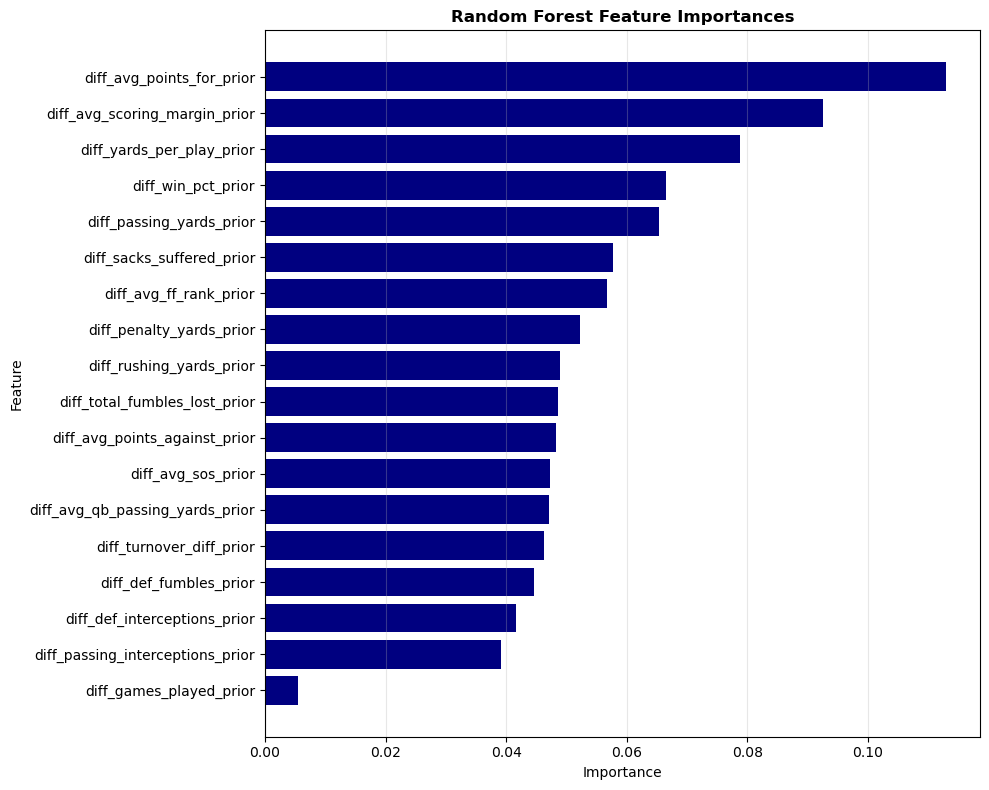

In [54]:
# Visualize Feature Importances

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='navy')
plt.xlabel('Importance', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [55]:
# Select Top 10 Features

top_n = 10
top_features = importance_df.head(top_n)['Feature'].tolist()

print("\n" + "="*80)
print(f"TOP {top_n} FEATURES SELECTED")
print("="*80)
for i, feat in enumerate(top_features, 1):
    importance = importance_df[importance_df['Feature'] == feat]['Importance'].values[0]
    print(f"   {i:2d}. {feat:40s}  {importance:.4f}")

# Create reduced feature set
X_reduced = X[top_features]
X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

# Scale the reduced features
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

print(f"\nReduced feature matrix created: {X_reduced.shape}")


TOP 10 FEATURES SELECTED
    1. diff_avg_points_for_prior                 0.1129
    2. diff_avg_scoring_margin_prior             0.0926
    3. diff_yards_per_play_prior                 0.0788
    4. diff_win_pct_prior                        0.0664
    5. diff_passing_yards_prior                  0.0653
    6. diff_sacks_suffered_prior                 0.0576
    7. diff_avg_ff_rank_prior                    0.0567
    8. diff_penalty_yards_prior                  0.0522
    9. diff_rushing_yards_prior                  0.0488
   10. diff_total_fumbles_lost_prior             0.0485

Reduced feature matrix created: (1842, 10)


In [56]:
# Train Logistic Regression on Top Features

print("\n" + "="*80)
print("LOGISTIC REGRESSION - TRAINING ON TOP FEATURES")
print("="*80)

# Train logistic regression on reduced feature set
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("\nTraining Logistic Regression on top 10 features...")
log_reg.fit(X_train_reduced_scaled, y_train)

print("\nLogistic Regression trained successfully")


LOGISTIC REGRESSION - TRAINING ON TOP FEATURES

Training Logistic Regression on top 10 features...

Logistic Regression trained successfully


In [57]:
# Display Model Coefficients and Intercept

print("\n" + "="*80)
print("MODEL COEFFICIENTS AND INTERCEPT")
print("="*80)

print(f"\nIntercept (bias term): {log_reg.intercept_[0]:.6f}")

print(f"\nFeature Coefficients (weights):")
print("\n")
print(f"{'':4s}{'Feature':<42s}{'Coefficient':>15s}{'Impact':<10s}")
print("-" * 80)

for i, (feature, coef) in enumerate(zip(top_features, log_reg.coef_[0]), 1):
    # Determine impact interpretation
    if abs(coef) > 0.3:
        impact = "Strong"
    elif abs(coef) > 0.15:
        impact = "Moderate"
    else:
        impact = "Weak"
    
    # Show direction
    direction = "+" if coef > 0 else ""
    
    # Clean feature name for display
    clean_name = feature.replace('diff_', '').replace('_prior', '')
    
    print(f"{i:2d}. {clean_name:<42s}{direction}{coef:>14.6f}   {impact}")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("""
Positive coefficient (+): When home team is better in this stat, they're MORE likely to win
Negative coefficient (-): When home team is better in this stat, they're LESS likely to win

Magnitude: Larger absolute values = more important to the model

Example:
  If 'avg_points_for' has coefficient +0.20:
  → Home team scoring 10 more points/game increases win probability
  
  If 'penalty_yards' has coefficient -0.15:
  → Home team having more penalties DECREASES win probability
""")


MODEL COEFFICIENTS AND INTERCEPT

Intercept (bias term): 0.250529

Feature Coefficients (weights):


    Feature                                       CoefficientImpact    
--------------------------------------------------------------------------------
 1. avg_points_for                                 -0.088219   Weak
 2. avg_scoring_margin                        +      0.303008   Strong
 3. yards_per_play                            +      0.300675   Strong
 4. win_pct                                   +      0.088948   Weak
 5. passing_yards                             +      0.074649   Weak
 6. sacks_suffered                                 -0.231345   Moderate
 7. avg_ff_rank                                    -0.185303   Moderate
 8. penalty_yards                             +      0.020768   Weak
 9. rushing_yards                             +      0.002446   Weak
10. total_fumbles_lost                        +      0.201658   Moderate

INTERPRETATION

Positive coefficient (+):

In [58]:
# Evaluate & Interpret Model Performance

# ---------------------------------------------------------------------------
# 1. Generate Predictions
# ---------------------------------------------------------------------------
# We predict class labels (0/1) for both train and test sets.
# Using both lets us check for overfitting vs generalization.
y_train_pred = log_reg.predict(X_train_reduced_scaled)
y_test_pred  = log_reg.predict(X_test_reduced_scaled)

# ---------------------------------------------------------------------------
# 2. Compute Accuracy Metrics
# ---------------------------------------------------------------------------
# Accuracy = (Correct Predictions) / (Total Predictions)
# While simple, it gives a quick sanity check on performance.
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

# Difference between train and test accuracy is a crude
# but useful indicator of overfitting.
acc_gap = train_acc - test_acc

# ---------------------------------------------------------------------------
# 3. Display Results in a Structured Way
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

print(f"\nModel: Logistic Regression")
print(f"Feature Selection: Top {top_n} most informative features (after reduction + scaling)")

print("\nAccuracy Metrics:")
print(f"   Training Accuracy : {train_acc:.4f}")
print(f"   Testing Accuracy  : {test_acc:.4f}")
print(f"   Generalization Gap: {acc_gap:.4f}")

# ---------------------------------------------------------------------------
# 4. Quick Interpretation
# ---------------------------------------------------------------------------
if acc_gap > 0.05:
    print("\n⚠️  Interpretation:")
    print("   The model performs significantly better on training data.")
    print("   Possible overfitting — consider stronger regularization or fewer features.")
else:
    print("\n Interpretation:")
    print("   Training and testing performance are well-aligned.")
    print("   The model appears to generalize reasonably well.")


MODEL PERFORMANCE SUMMARY

Model: Logistic Regression
Feature Selection: Top 10 most informative features (after reduction + scaling)

Accuracy Metrics:
   Training Accuracy : 0.6388
   Testing Accuracy  : 0.6585
   Generalization Gap: -0.0197

 Interpretation:
   Training and testing performance are well-aligned.
   The model appears to generalize reasonably well.


In [59]:
# ============================================================================
# STEP 11: Predict winner of Super Bowl LX 2026
# ============================================================================

# Super Bowl LX: Patriots vs Seahawks
# February 8, 2026 at Levi's Stadium, Santa Clara, CA
# Note: Super Bowl is played at neutral site

home_team = "SEA"   # Seattle Seahawks (NFC Champion)
away_team = "NE"    # New England Patriots (AFC Champion)
season_year = 2025  # Using 2025 season data (current season)

# Team name mapping for display
team_names = {
    "SEA": "Seattle Seahawks",
    "NE": "New England Patriots"
}

print("\n" + "="*80)
print(f"SUPER BOWL LX PREDICTION: {away_team} vs {home_team}")
print("February 8, 2026 - Levi's Stadium, Santa Clara, CA")
print("="*80)

# Get latest complete data for both teams
home_all_data = team_prior_features[
    (team_prior_features['team'] == home_team) & 
    (team_prior_features['season'] == season_year)
].sort_values('week', ascending=False)

away_all_data = team_prior_features[
    (team_prior_features['team'] == away_team) & 
    (team_prior_features['season'] == season_year)
].sort_values('week', ascending=False)

if len(home_all_data) == 0 or len(away_all_data) == 0:
    print(f"\n⚠️  ERROR: One or both teams have NO data for {season_year} season!")
else:
    # Filter to rows with NO NaN values
    home_complete = home_all_data.dropna()
    away_complete = away_all_data.dropna()
    
    if len(home_complete) == 0 or len(away_complete) == 0:
        print(f"\n⚠️  ERROR: No complete data found for one or both teams!")
    else:
        # Get the latest week that exists for BOTH teams with complete data
        home_latest_week = home_complete.iloc[0]['week']
        away_latest_week = away_complete.iloc[0]['week']
        latest_common_week = min(home_latest_week, away_latest_week)
        
        # Get stats for that week
        home_stats = home_complete[home_complete['week'] == latest_common_week].head(1)
        away_stats = away_complete[away_complete['week'] == latest_common_week].head(1)
        
        if len(home_stats) == 0 or len(away_stats) == 0:
            print(f"\n⚠️  ERROR: Could not find matching week {latest_common_week} for both teams")
        else:
            print(f"\nUsing Week {int(latest_common_week)} data (latest with complete stats for both teams)")
            print(f"   {home_team}: {home_stats['games_played_prior'].values[0]:.0f} games played")
            print(f"   {away_team}: {away_stats['games_played_prior'].values[0]:.0f} games played")
            
            # Neutral-site adjustment:
            # The model was trained with a "home" vs "away" framing.
            # For a neutral-site game, we remove home-field bias by averaging both orientations:
            #   p1 = P(SEA wins | SEA home, NE away)
            #   p2 = P(SEA wins | NE home, SEA away) = 1 - P(NE wins | NE home, SEA away)
            #   p_neutral = (p1 + p2) / 2
            
            # Prediction 1: SEA as "home", NE as "away"
            diff_data_sea_home = {}
            for feature in top_features:
                orig_feature = feature.replace('diff_', '')
                sea_val = home_stats[orig_feature].values[0] if orig_feature in home_stats.columns else 0
                ne_val = away_stats[orig_feature].values[0] if orig_feature in away_stats.columns else 0
                diff_data_sea_home[feature] = [sea_val - ne_val]
            
            prediction_df_sea_home = pd.DataFrame(diff_data_sea_home)
            prediction_scaled_sea_home = scaler_reduced.transform(prediction_df_sea_home)
            p_sea_home = log_reg.predict_proba(prediction_scaled_sea_home)[0, 1]
            
            # Prediction 2: NE as "home", SEA as "away" (flip the differences)
            diff_data_ne_home = {}
            for feature in top_features:
                orig_feature = feature.replace('diff_', '')
                sea_val = home_stats[orig_feature].values[0] if orig_feature in home_stats.columns else 0
                ne_val = away_stats[orig_feature].values[0] if orig_feature in away_stats.columns else 0
                diff_data_ne_home[feature] = [ne_val - sea_val]
            
            prediction_df_ne_home = pd.DataFrame(diff_data_ne_home)
            prediction_scaled_ne_home = scaler_reduced.transform(prediction_df_ne_home)
            p_ne_wins_as_home = log_reg.predict_proba(prediction_scaled_ne_home)[0, 1]
            
            # Average both orientations for neutral-site probability
            prediction_proba = (p_sea_home + (1 - p_ne_wins_as_home)) / 2
            
            print(f"\n   When SEA treated as home: SEA wins {p_sea_home:.1%}")
            print(f"   When NE treated as home: SEA wins {(1 - p_ne_wins_as_home):.1%}")
            
            # Display results
            print("\n" + "="*80)
            print("PREDICTION RESULTS (Neutral Site Adjustment Applied)")
            print("="*80)
            
            
            if prediction_proba > 0.5:
                winner = home_team
                winner_name = team_names[home_team]
                confidence = prediction_proba * 100
            else:
                winner = away_team
                winner_name = team_names[away_team]
                confidence = (1 - prediction_proba) * 100
            
            print(f"\n🏆 SUPER BOWL LX CHAMPION: {winner_name}")
            print(f"   Model Confidence: {confidence:.1f}%")
            print(f"\n   Seattle Seahawks (NFC) win probability: {prediction_proba:.1%}")
            print(f"   New England Patriots (AFC) win probability: {(1-prediction_proba):.1%}")
            
            # Show key feature differences (using SEA-home orientation for display)
            print(f"\n📊 Key Feature Differences (SEA - NE):")
            for feat in top_features[:5]:  # Show top 5
                val = prediction_df_sea_home[feat].values[0]
                direction = "↑" if val > 0 else "↓" if val < 0 else "="
                print(f"   {direction} {feat.replace('diff_', '').replace('_prior', '')}: {val:+.3f}")


SUPER BOWL LX PREDICTION: NE vs SEA
February 8, 2026 - Levi's Stadium, Santa Clara, CA

Using Week 21 data (latest with complete stats for both teams)
   SEA: 18 games played
   NE: 19 games played

   When SEA treated as home: SEA wins 62.9%
   When NE treated as home: SEA wins 52.2%

PREDICTION RESULTS (Neutral Site Adjustment Applied)

🏆 SUPER BOWL LX CHAMPION: Seattle Seahawks
   Model Confidence: 57.6%

   Seattle Seahawks (NFC) win probability: 57.6%
   New England Patriots (AFC) win probability: 42.4%

📊 Key Feature Differences (SEA - NE):
   ↑ avg_points_for: +1.006
   ↑ avg_scoring_margin: +2.292
   ↓ yards_per_play: -0.338
   ↓ win_pct: -0.009
   ↓ passing_yards: -25.599


In [61]:
from datetime import datetime
prediction_time = datetime.now().strftime("%B %d, %Y at %I:%M:%S %p")
print(f"\n📅 Prediction generated: {prediction_time}")


📅 Prediction generated: February 08, 2026 at 02:05:32 PM
